# Notebook Solution for House Prices Prediction

In [1]:
import pandas as pd
df = pd.read_csv('./house-prices-advanced-regression-techniques/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.shape

(1460, 81)

In [3]:
nulos = df.isna().sum()
columns_nulas = nulos[nulos>0]
columns_nulas = columns_nulas.sort_values(ascending=False)
print(columns_nulas)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


1. PoolQC          1453 -> Pool Quality
2. MiscFeature     1406 -> Miscellaneous feature not covered in other categories
3. Alley           1369 -> Type of alley access to property -> tipo de call
4. Fence           1179 -> Fence quality
5. MasVnrType       872 -> Masonry veneer type
6. FireplaceQu      690 -> FireplaceQu: Fireplace quality
7. LotFrontage      259 -> Linear feet of street connected to property
8. GarageType        81 -> Garage location (2types, attaches to home, basement, but in, car port, ...)
9. GarageYrBlt       81 -> Year garage was built
10. GarageFinish      81 -> Interior finish of the garage
11. GarageQual        81 -> Size of garage in car capacity
12. GarageCond        81 -> Garage condition (excellent, good typical) (OrdinalEncoder)
13. BsmtFinType2      38 -> Quality of second finished area (if present)
14. BsmtExposure      38 -> Walkout or garden level basement walls
15. BsmtFinType1      37 -> Quality of basement finished area
16. BsmtCond          37 -> General condition of the basement
17. BsmtQual          37 -> BsmtQual: Height of the basement
18. MasVnrArea         8 -> Masonry veneer area in square feet
19. Electrical         1 -> Electrica System

In [4]:
# los NA de las piscinas es simplemente que no tiene piscina, por lo tanto lo rellenamos
df_limpio = df.copy()
df_limpio['PoolQC'] = df_limpio['PoolQC'].fillna("None")

# los na de miscfeatures tampco son reales, simplemente no tienen cietos datos. A la hora de montar
# la clasificación, me hará falta saber si importa más la casa por que tenga más características o no
df_limpio['MiscFeature'] = df_limpio['MiscFeature'].fillna("None")

# lo mismo pasa con alley
df_limpio['Alley'] = df_limpio['Alley'].fillna("None")
df_limpio['Fence'] = df_limpio['Fence'].fillna("None")
df_limpio['FireplaceQu'] = df_limpio['FireplaceQu'].fillna("None")
df_limpio['GarageType'] = df_limpio['GarageType'].fillna("None")
df_limpio['GarageFinish'] = df_limpio['GarageFinish'].fillna("None")
df_limpio['GarageQual'] = df_limpio['GarageQual'].fillna("None")
df_limpio['GarageCond'] = df_limpio['GarageCond'].fillna("None")
df_limpio['BsmtQual'] = df_limpio['BsmtQual'].fillna("None")
df_limpio['BsmtCond'] = df_limpio['BsmtCond'].fillna("None")
df_limpio['BsmtExposure'] = df_limpio['BsmtExposure'].fillna("None basement")
df_limpio['BsmtFinType1'] = df_limpio['BsmtFinType1'].fillna("None")
df_limpio['BsmtFinType2'] = df_limpio['BsmtFinType2'].fillna("None")

# eliminamos el valor de electrical
df_limpio = df_limpio.dropna(subset=['Electrical'])

In [5]:
nulos = df_limpio.isna().sum()
columns_nulas = nulos[nulos>0]
columns_nulas = columns_nulas.sort_values(ascending=False)
print(columns_nulas)

MasVnrType     871
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


Quedan pendientes:
- MasVnrType si no tiene revestimiento -> none, y su area tambien 0'
- LotFrontage: Podríamos ver que tan dispersos están sus datos para tomar la media o mediana para aquellos valores nulos
- GargeUYrBlt: Igual que arriba
- Electrical: Me falta un valor qeu lo voy a eliminar

In [6]:
import matplotlib.pyplot as plt
import numpy as np

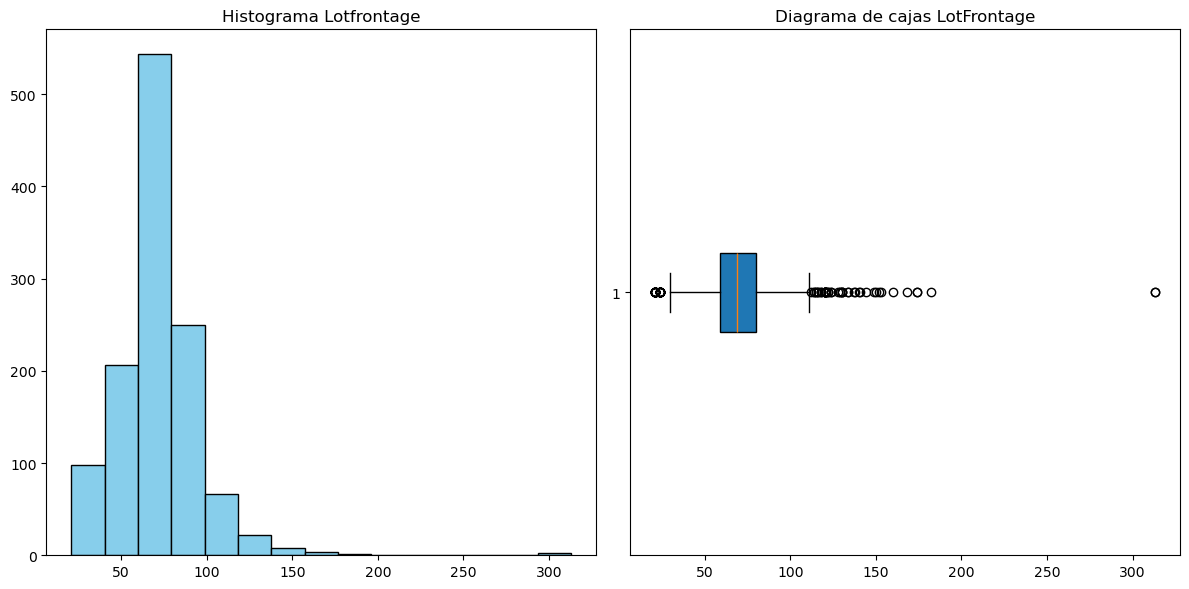

In [7]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1) # 1 fila, 2 columnsa, posicion 1
plt.hist(df_limpio['LotFrontage'].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma Lotfrontage')

plt.subplot(1, 2, 2)
plt.boxplot(df_limpio['LotFrontage'].dropna(), vert=False, patch_artist=True)
plt.title('Diagrama de cajas LotFrontage')

plt.tight_layout()
plt.show()

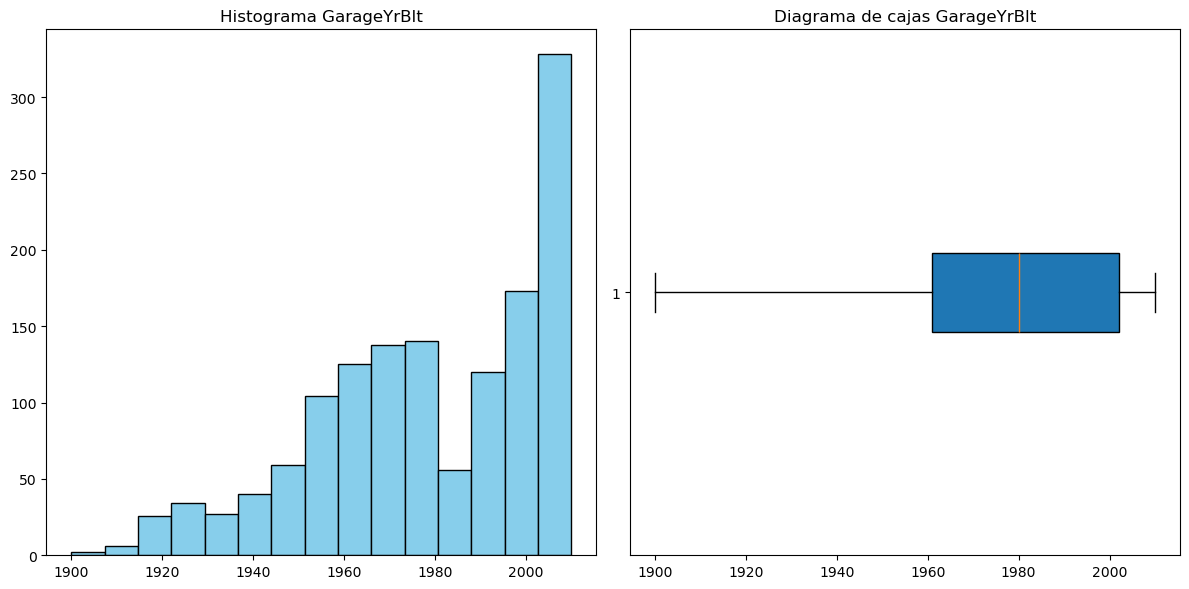

In [8]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1) # 1 fila, 2 columnsa, posicion 1
plt.hist(df_limpio['GarageYrBlt'].dropna(), bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma GarageYrBlt')

plt.subplot(1, 2, 2)
plt.boxplot(df_limpio['GarageYrBlt'].dropna(), vert=False, patch_artist=True)
plt.title('Diagrama de cajas GarageYrBlt')

plt.tight_layout()
plt.show()

Obteniendo el resultado del histograma, determinamos que la media no es una buena medida para tomar en este caso. Por lo tanto, rellenaremos los nulos e LotFrontage y garageYrBuilt con la mediana

In [9]:
df_limpio['LotFrontage'] = df_limpio['LotFrontage'].fillna(df_limpio['LotFrontage'].median())

In [10]:
df_limpio['GarageYrBlt'] = df_limpio['GarageYrBlt'].fillna(df_limpio['GarageYrBlt'].median())

In [11]:
def verNulos(df):
    nulas = df.isna().sum()
    col_nulas = nulas[nulas>0]
    print(col_nulas.sort_values(ascending=False))

In [12]:
verNulos(df_limpio)

MasVnrType    871
MasVnrArea      8
dtype: int64


Text(0.5, 1.0, 'Box Masvnrarea')

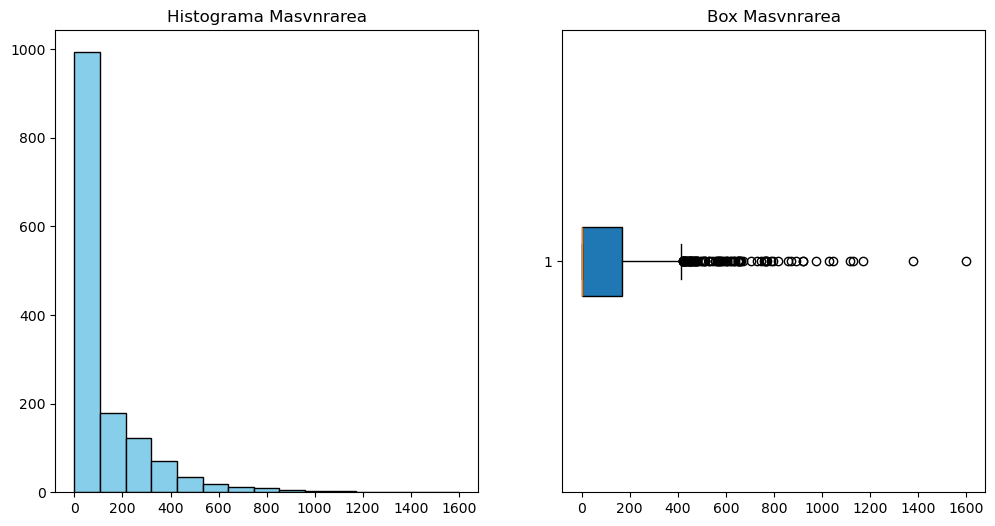

In [13]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df_limpio['MasVnrArea'].dropna(), color='skyblue', bins=15, edgecolor='black')
plt.title('Histograma Masvnrarea')

plt.subplot(1,2,2)
plt.boxplot(df_limpio['MasVnrArea'].dropna(), vert=False, patch_artist=True)
plt.title('Box Masvnrarea')

In [14]:
df_limpio['MasVnrArea'] = df_limpio['MasVnrArea'].fillna(df_limpio['MasVnrArea'].median())

In [15]:
df_limpio['MasVnrType'] = df_limpio['MasVnrType'].fillna('None')

## Preprocesamiento de los datos con Pipeline

In [29]:
df_p = pd.read_csv('./house-prices-advanced-regression-techniques/train.csv')

col_num = X_bruto.select_dtypes(include=['int64', 'float64']).columns.tolist()

col_cat_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                     'BsmtFinType2', 'MasVnrType']
col_cat_mediana = ['Electrical']

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

procesador_numerico = Pipeline([
    ('inputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transf_cat_none = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant', fill_value='None')),
    # handle_unknown='ignore' es la magia que soluciona tu problema con get_dummies. 
    # Si llega una categoría nueva, la ignora sin dar error.
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

trans_moda = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

preprocesador = ColumnTransformer(
    transformers= [
        ('num', procesador_numerico, col_num),
        ('cat_none', transf_cat_none, col_cat_none),
        ('cat_mediana', trans_moda, col_cat_mediana)
    ], 
    remainder='drop'
)

In [46]:
X_bruto = df_p.drop('SalePrice', axis=1)
y_bruto = df_p['SalePrice']
X_train_bruto, x_test_bruto, y_train, y_test = train_test_split(X_bruto, y_bruto, random_state=42, test_size=0.2)

# Standard Linear Regression

- Modelo: LinearRegression
- Scaler: StandardScaler
- Feature Engineer: PCA

In [34]:
df_num = pd.get_dummies(df_limpio, drop_first=True)

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

X = df_num.drop('SalePrice', axis=1)
y = df_num['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.32, random_state=42)

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

pip = Pipeline([
    ('preprocessor', preprocesador),
    # ('scaler', StandardScaler()),
    # ('PCA', PCA()),
    ('model', LinearRegression())
])

In [73]:
param_grid = {
    # 'PCA__n_components': [2, 5, 10, 15],
    'model__fit_intercept': [True, False]
}

In [74]:
search = GridSearchCV(
    estimator=pip,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

search.fit(X_train_bruto, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = search.predict(x_test_bruto)

In [76]:
import numpy as np
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {np.sqrt(mse)}")

R2: 0.6854556092663188
MAE: 34118.77235964374
MSE: 2412658083.5682626
RMSE: 49118.815982963824


In [55]:
print(f"Train score {search.score(X_train_bruto, y_train)}")

Train score 0.6041875581081573


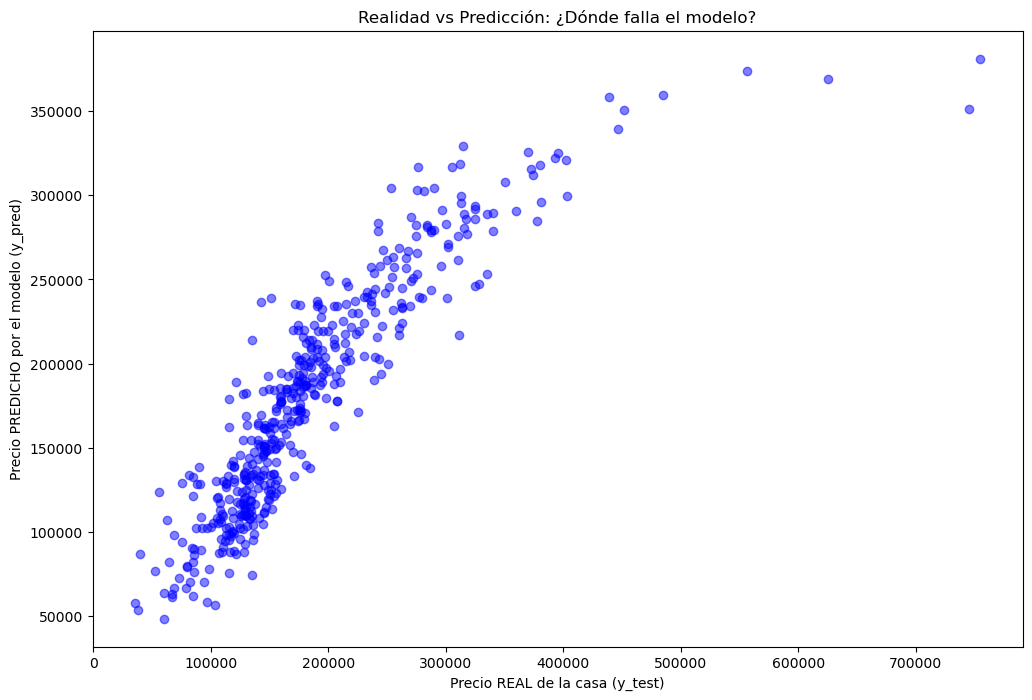

In [24]:
plt.figure(figsize=(12,8))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.title('Realidad vs Predicción: ¿Dónde falla el modelo?')
plt.xlabel('Precio REAL de la casa (y_test)')
plt.ylabel('Precio PREDICHO por el modelo (y_pred)')
plt.show()

# Regressor Forest

In [77]:
from sklearn.ensemble import RandomForestRegressor

pip_forest = Pipeline([
    ('preprocessor', preprocesador),
    # ('scaler', StandardScaler()),
    # ('PCA', PCA()),
    ('model', RandomForestRegressor())
])

In [78]:
param_grid = {
    # 'PCA__n_components': [10, 20, 30],
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 15, 25],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [79]:
import warnings

# Silenciar todas las advertencias
warnings.filterwarnings('ignore')

regresor_search = GridSearchCV(
    estimator=pip_forest,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

regresor_search.fit(X_train_bruto, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 15, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [80]:
random_y_pred = regresor_search.predict(x_test_bruto)

In [81]:
r2 = r2_score(y_test, random_y_pred)
mae = mean_absolute_error(y_test, random_y_pred)
mse = mean_squared_error(y_test, random_y_pred)
print(f"Train score {search.score(X_train_bruto, y_train)}")
print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {np.sqrt(mse)}")

Train score 0.7006870032802899
R2: 0.7103139107593084
MAE: 30540.266148671904
MSE: 2221986802.1604247
RMSE: 47137.955006135184


# XGBoost Regressor

In [82]:
from xgboost import XGBRegressor

pip_xgb = Pipeline([
    ('preprocessor', preprocesador),
    # ('scaler', StandardScaler()),
    # ('PCA', PCA()),
    ('model', XGBRegressor(objective='reg:squarederror')) # indicamos lo que queremos optimizar
])

In [83]:
param_grid = {
    # 'PCA__n_components': [5, 10, 15],
    'model__n_estimators': [100, 250, 300],
    'model__learning_rate': [0.05, 0.1], # pasos pequeños para evitar overfit
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0]
}

In [64]:
search_xgb = GridSearchCV(
    estimator=pip_xgb,
    param_grid=param_grid,
    cv=5, 
    verbose=1,
    scoring='r2'
)

search_xgb.fit(X_train_bruto, y_train)
y_pred_xgb = search_xgb.predict(x_test_bruto)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [67]:
print(f"Train score: {search_xgb.score(X_train_bruto, y_train)}")
print(f"R2: {r2_score(y_test, y_pred_xgb)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb)}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb))}")
print("==============================")
print("Best model params")
print(f"Best params: {search_xgb.best_params_}")
print(f"Best score: {search_xgb.best_score_}")

Train score: 0.8290724754333496
R2: 0.6534616947174072
MAE: 34341.6328125
MSE: 2658062080.0
RMSE: 51556.39708125462
Best model params
Best params: {'PCA__n_components': 10, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best score: 0.6130061745643616


## Final & Kaggle
- Me quedo con el modelo más sencillo y que mejor funciona: RegressorForest

In [ ]:
df_kaggle = pd.read_csv('./house-prices-advanced-regression-techniques/test.csv')
verNulos(df_kaggle)

In [ ]:
predicciones_finales = regresor_search.predict(df_num)

In [ ]:
submission = pd.DataFrame({
    'Id': df_kaggle['Id'], # La columna identificadora de la casa
    'SalePrice': predicciones_finales # Tus predicciones
})
submission.to_csv('mi_entrega_rf.csv', index=False)

print("¡Archivo exportado con éxito y listo para subir!")